<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
Aprendizaje no supervisado - K-Means para agrupacion de casas
</h1>

In [6]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings("ignore")

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Carga del dataset y seleccion de variables
</h2>

In [2]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"
ruta_local = "housing.csv"

if os.path.exists(ruta_local):
    df = pd.read_csv(ruta_local)
else:
    df = pd.read_csv(url)

df = df[["Latitude", "Longitude", "MedInc"]].copy()

print("Forma del dataset:", df.shape)
display(df.head())

revision_calidad = pd.DataFrame({
    "tipo_de_dato": df.dtypes,
    "valores_nulos": df.isnull().sum(),
    "valores_unicos": df.nunique()
})

display(revision_calidad)

X = df[["Latitude", "Longitude", "MedInc"]]

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)

Forma del dataset: (20640, 3)


,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


,tipo_de_dato,valores_nulos,valores_unicos
Latitude,float64,0,862
Longitude,float64,0,844
MedInc,float64,0,12928


Forma de X_train: (16512, 3)
Forma de X_test: (4128, 3)


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En este bloque, el archivo se cargo bien y quedaron seleccionadas las <span style="color:#D11A2A; font-weight:bold;">3 columnas</span> que pide la actividad: <span style="color:#D11A2A; font-weight:bold;">Latitude</span>, <span style="color:#D11A2A; font-weight:bold;">Longitude</span> y <span style="color:#D11A2A; font-weight:bold;">MedInc</span>.<br>
El dataset tiene <span style="color:#D11A2A; font-weight:bold;">20.640 filas</span> y <span style="color:#D11A2A; font-weight:bold;">no hay datos vacios</span> en ninguna de esas columnas.<br>
Tambien veo que los datos se dividieron bien en dos partes: <span style="color:#D11A2A; font-weight:bold;">16.512 filas para train</span> y <span style="color:#D11A2A; font-weight:bold;">4.128 filas para test</span>. Con esto ya podemos pasar al modelo.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Escalado de las variables
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Antes de usar <span style="color:#D11A2A; font-weight:bold;">K-Means</span>, voy a escalar los datos para que las <span style="color:#D11A2A; font-weight:bold;">3 columnas</span> queden en una escala parecida.<br>
Esto es importante porque este modelo agrupa usando <span style="color:#D11A2A; font-weight:bold;">distancias</span>. Si una columna pesa mas que otra por sus valores, los grupos pueden salir mal.
</div>

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Media aproximada de cada columna en train escalado:")
print(X_train_scaled.mean(axis=0))

print("\nDesviacion estandar aproximada de cada columna en train escalado:")
print(X_train_scaled.std(axis=0))

Media aproximada de cada columna en train escalado:
[ 3.38574991e-15  1.77678716e-15 -6.32568933e-17]

Desviacion estandar aproximada de cada columna en train escalado:
[1. 1. 1.]


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En este bloque, el escalado salio bien.<br>
Las medias quedaron <span style="color:#D11A2A; font-weight:bold;">muy cerca de 0</span> y la desviacion estandar quedo en <span style="color:#D11A2A; font-weight:bold;">1</span> en las <span style="color:#D11A2A; font-weight:bold;">3 columnas</span>.<br>
Dicho de forma simple, ahora <span style="color:#D11A2A; font-weight:bold;">Latitude</span>, <span style="color:#D11A2A; font-weight:bold;">Longitude</span> y <span style="color:#D11A2A; font-weight:bold;">MedInc</span> quedaron medidas de forma pareja.<br>
Esto deja los datos listos para usar <span style="color:#D11A2A; font-weight:bold;">K-Means</span> sin que una columna tenga mas peso del que debe.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Metodo del codo
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Antes de entrenar el modelo final, voy a probar varios valores de <span style="color:#D11A2A; font-weight:bold;">k</span> para ver como cambia el error.<br>
La actividad pide usar <span style="color:#D11A2A; font-weight:bold;">6 clusters</span>, investigando vi que esta grafica ayuda a mostrar si esa cantidad tiene sentido y deja el analisis mejor defendido.
</div>

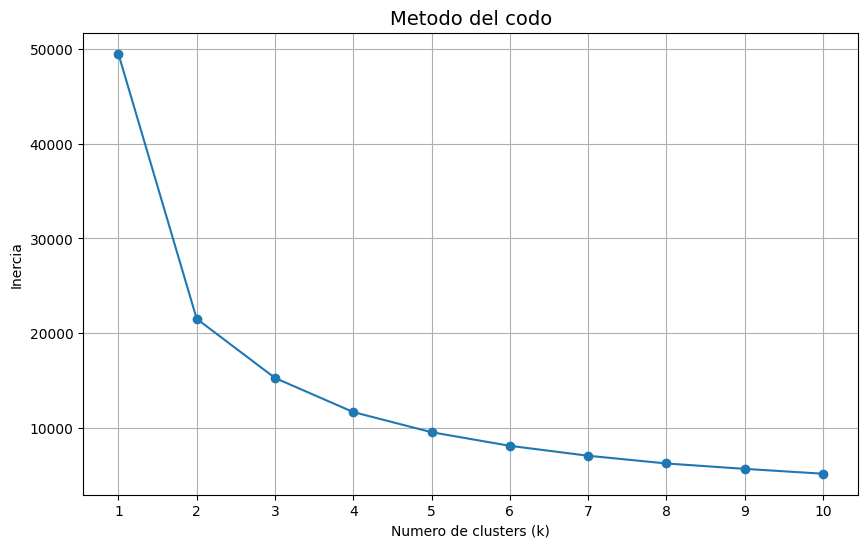

In [9]:
inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Metodo del codo", fontsize=14)
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En esta grafica se ve que la caida mas fuerte ocurre entre <span style="color:#D11A2A; font-weight:bold;">1 y 3 clusters</span>.<br>
A partir de ahi, la curva sigue bajando, pero cada vez <span style="color:#D11A2A; font-weight:bold;">menos</span>.<br>
Esto nos dice que separar las casas en grupos si tiene sentido, aunque despues de cierto punto la mejora ya no es tan grande.<br>
La actividad pide trabajar con <span style="color:#D11A2A; font-weight:bold;">6 clusters</span>, y esta grafica muestra que esa decision es razonable porque en esa zona la curva ya va perdiendo fuerza.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Entrenamiento de K-Means con 6 clusters
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Ahora voy a entrenar el modelo con <span style="color:#D11A2A; font-weight:bold;">6 clusters</span>, que es la cantidad que me piden.<br>
Despues voy a guardar el grupo de cada casa en una nueva columna llamada <span style="color:#D11A2A; font-weight:bold;">cluster</span> para poder analizar mejor como quedaron repartidas.
</div>

In [11]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

train_data = X_train.copy()
test_data = X_test.copy()

train_data["cluster"] = train_clusters
test_data["cluster"] = test_clusters

train_data["cluster"] = train_data["cluster"].astype("category")
test_data["cluster"] = test_data["cluster"].astype("category")

print("Primeras filas de train con cluster:")
display(train_data.head())

print("Cantidad de casas por cluster en train:")
display(train_data["cluster"].value_counts().sort_index())

Primeras filas de train con cluster:


,Latitude,Longitude,MedInc,cluster
14196,32.71,-117.03,3.2596,5
8267,33.77,-118.16,3.8125,5
17445,34.66,-120.48,4.1563,0
14265,32.69,-117.11,1.9425,5
2271,36.78,-119.80,3.5542,0


Cantidad de casas por cluster en train:


cluster
0    1321
1    3380
2     453
3    3931
4    2239
5    5188
Name: count, dtype: int64

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En este bloque, el modelo ya separo las casas en <span style="color:#D11A2A; font-weight:bold;">6 grupos</span> y guardo ese resultado en la columna <span style="color:#D11A2A; font-weight:bold;">cluster</span>.<br>
Veo que los grupos <span style="color:#D11A2A; font-weight:bold;">no tienen el mismo tamano</span>. Por ejemplo, el <span style="color:#D11A2A; font-weight:bold;">cluster 5</span> es el mas grande con <span style="color:#D11A2A; font-weight:bold;">5.188 casas</span>, mientras que el <span style="color:#D11A2A; font-weight:bold;">cluster 2</span> es el mas pequeno con <span style="color:#D11A2A; font-weight:bold;">453 casas</span>.<br>
Esto nos dice que el modelo encontro zonas o perfiles de casas que aparecen mucho y otros que aparecen poco. Ahora lo mas importante es ver esos grupos en una <span style="color:#D11A2A; font-weight:bold;">grafica</span> para entender como quedaron repartidos.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Grafica de dispersion de los clusters
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Ahora voy a representar los <span style="color:#D11A2A; font-weight:bold;">6 clusters</span> en una grafica de puntos usando <span style="color:#D11A2A; font-weight:bold;">Longitude</span> y <span style="color:#D11A2A; font-weight:bold;">Latitude</span>.<br>
Esta grafica es importante porque permite ver de forma clara <span style="color:#D11A2A; font-weight:bold;">como quedaron repartidos los grupos</span> en el mapa.
</div>

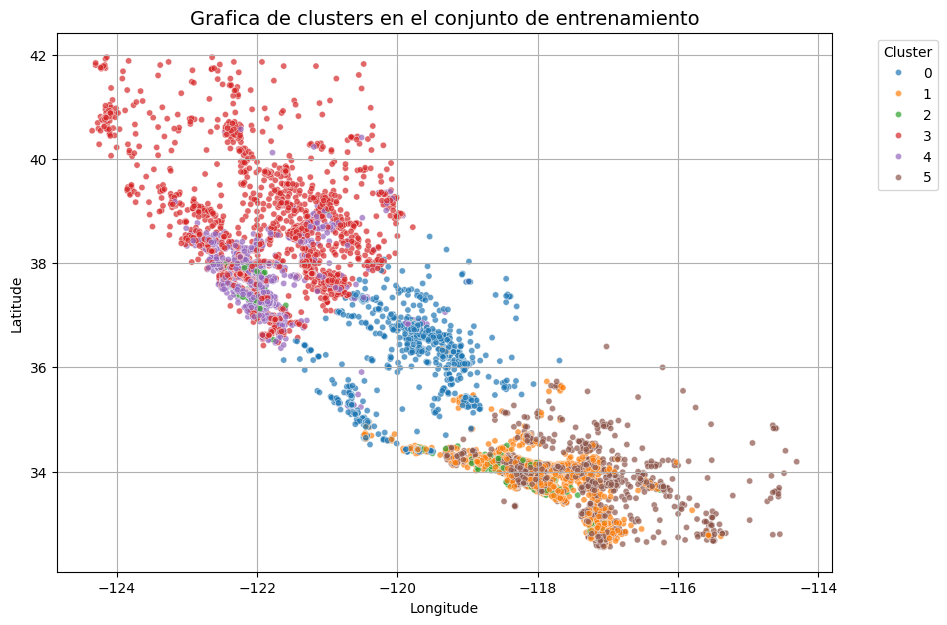

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=train_data,
    x="Longitude",
    y="Latitude",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.7
)

plt.title("Grafica de clusters en el conjunto de entrenamiento", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En esta grafica se ve que el modelo si logro formar <span style="color:#D11A2A; font-weight:bold;">grupos distintos</span> segun la ubicacion de las casas.<br>
Los clusters mas grandes se reparten sobre todo entre la <span style="color:#D11A2A; font-weight:bold;">zona norte</span> y la <span style="color:#D11A2A; font-weight:bold;">zona sur</span>, asi que la posicion geografica esta influyendo bastante en la agrupacion.<br>
Tambien se nota que algunos grupos quedan <span style="color:#D11A2A; font-weight:bold;">bien separados</span>, mientras que otros se mezclan un poco en zonas cercanas. Eso significa que hay areas donde las casas se parecen mucho entre si y otras donde la division no es tan marcada.<br>
En general, la grafica muestra que el modelo encontro una separacion coherente y que los <span style="color:#D11A2A; font-weight:bold;">6 clusters</span> no fueron asignados al azar.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Prediccion sobre el conjunto de test
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Ahora voy a usar el modelo ya entrenado para asignar un <span style="color:#D11A2A; font-weight:bold;">cluster</span> a las casas del conjunto <span style="color:#D11A2A; font-weight:bold;">test</span>.<br>
Despues voy a poner esos puntos sobre la grafica para comprobar si las casas nuevas caen de forma parecida a los grupos que ya se habian formado.
</div>

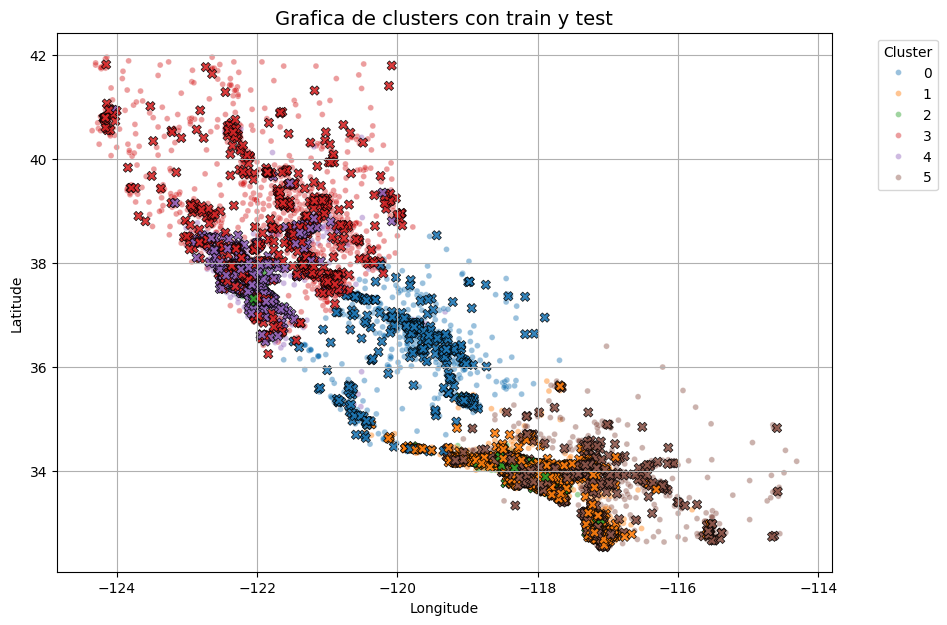

In [13]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=train_data,
    x="Longitude",
    y="Latitude",
    hue="cluster",
    palette="tab10",
    s=18,
    alpha=0.45,
    legend="full"
)

sns.scatterplot(
    data=test_data,
    x="Longitude",
    y="Latitude",
    hue="cluster",
    palette="tab10",
    s=45,
    alpha=0.9,
    marker="X",
    edgecolor="black",
    legend=False
)

plt.title("Grafica de clusters con train y test", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En esta grafica se ve que los puntos de <span style="color:#D11A2A; font-weight:bold;">test</span> caen, en general, sobre las mismas zonas donde ya estaban los grupos de <span style="color:#D11A2A; font-weight:bold;">train</span>.<br>
Eso quiere decir que el modelo esta colocando las casas nuevas de una forma <span style="color:#D11A2A; font-weight:bold;">coherente</span> con los grupos que aprendio antes.<br>
Tambien se nota que en algunas zonas los puntos se mezclan un poco mas, pero la forma general de los clusters se mantiene.<br>
En resumen, la prediccion sobre test se ve <span style="color:#D11A2A; font-weight:bold;">satisfactoria</span> porque las casas nuevas no quedaron repartidas al azar, sino siguiendo el mismo patron de la grafica anterior.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Modelo supervisado para predecir los clusters
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Ahora voy a entrenar un modelo supervisado para predecir el <span style="color:#D11A2A; font-weight:bold;">cluster</span> de cada casa.<br>
Voy a usar <span style="color:#D11A2A; font-weight:bold;">RandomForestClassifier</span> porque segun tengo entendido suele funcionar bien cuando la separacion entre grupos no sigue una forma tan recta o tan simple.
</div>

In [14]:
y_train = train_data["cluster"].astype(int)
y_test = test_data["cluster"].astype(int)

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy de RandomForestClassifier:", accuracy_rf)

Accuracy de RandomForestClassifier: 0.9951550387596899


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
El modelo dio un <span style="color:#D11A2A; font-weight:bold;">accuracy de 0.9952</span>, que es un resultado <span style="color:#D11A2A; font-weight:bold;">muy alto</span>.<br>
Dicho de forma simple, el modelo casi siempre logra colocar cada casa en el <span style="color:#D11A2A; font-weight:bold;">mismo grupo</span> que habia marcado K-Means.<br>
Esto muestra que los clusters que salieron antes quedaron lo bastante claros como para que un modelo supervisado los pueda aprender y repetir casi sin errores.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Metricas del modelo supervisado
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Ahora voy a revisar el resultado con mas detalle usando <span style="color:#D11A2A; font-weight:bold;">classification_report</span> y <span style="color:#D11A2A; font-weight:bold;">confusion_matrix</span>.<br>
Esto sirve para ver si el modelo acierta bien en <span style="color:#D11A2A; font-weight:bold;">todos los grupos</span> o si hay algunos clusters donde se equivoca mas.
</div>

Classification report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       337
           1       1.00      1.00      1.00       829
           2       1.00      0.98      0.99       112
           3       0.99      0.99      0.99       962
           4       0.99      1.00      0.99       514
           5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



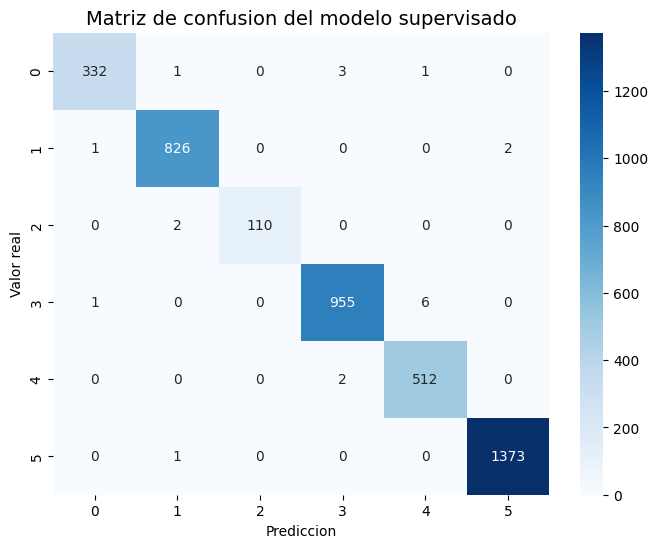

In [16]:
print("Classification report:\n")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion del modelo supervisado", fontsize=14)
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
El resultado final es <span style="color:#D11A2A; font-weight:bold;">muy bueno</span>.<br>
El modelo tiene un <span style="color:#D11A2A; font-weight:bold;">accuracy casi perfecto</span> y en el reporte se ve que todos los grupos tienen valores de <span style="color:#D11A2A; font-weight:bold;">precision</span>, <span style="color:#D11A2A; font-weight:bold;">recall</span> y <span style="color:#D11A2A; font-weight:bold;">f1-score</span> muy altos.<br>
En la matriz de confusion tambien se confirma lo mismo: casi todos los valores quedaron en la <span style="color:#D11A2A; font-weight:bold;">diagonal principal</span>, que es donde estan los aciertos.<br>
Los errores que aparecen son <span style="color:#D11A2A; font-weight:bold;">muy pocos</span> y estan repartidos entre algunos clusters cercanos.<br>
En resumen, el modelo supervisado aprendio muy bien la clasificacion que habia generado <span style="color:#D11A2A; font-weight:bold;">K-Means</span> y logra repetirla con un nivel de acierto muy alto.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Conclusion final
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En este proyecto use <span style="color:#D11A2A; font-weight:bold;">K-Means</span> para agrupar casas usando <span style="color:#D11A2A; font-weight:bold;">Latitude</span>, <span style="color:#D11A2A; font-weight:bold;">Longitude</span> y <span style="color:#D11A2A; font-weight:bold;">MedInc</span>.<br>
El modelo logro formar <span style="color:#D11A2A; font-weight:bold;">6 grupos</span> con una distribucion clara en el mapa, y al probar con el conjunto de <span style="color:#D11A2A; font-weight:bold;">test</span> se vio que las casas nuevas cayeron en zonas coherentes con esos mismos grupos.<br>
Despues use un modelo supervisado para intentar repetir esa clasificacion y el resultado fue <span style="color:#D11A2A; font-weight:bold;">muy alto</span>, con un accuracy cercano a <span style="color:#D11A2A; font-weight:bold;">0.9952</span>.<br>
En resumen, este trabajo muestra que si es posible agrupar las casas de forma util usando su <span style="color:#D11A2A; font-weight:bold;">ubicacion</span> y el <span style="color:#D11A2A; font-weight:bold;">ingreso medio</span>, y que esos grupos quedan lo bastante claros como para que otro modelo los aprenda casi sin errores.
</div>